In [1]:
# First install swig
!pip install swig

# Try installing box2d-py with specific version
!pip install box2d-py==2.3.8

# Then install gymnasium with box2d
!pip install gymnasium[box2d] torch numpy matplotlib pandas tqdm seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.9 MB ? eta -:--:--


   ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━ 0.7/1.9 MB 20.9 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/374.5 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 11.7 MB/s eta 0:00:00


  Preparing metadata (setup.py) ... done


  Created wheel for box2d-py: filename=box2d_py-2.3.8-cp312-cp312-linux_x86_64.whl size=2398778 sha256=c0736119aff241eeba5d4616b915b78000f028e561bc991806ae2ec7c32ecc56
  Stored in directory: /root/.cache/pip/wheels/d6/3c/ab/b6fd75459cadc56f4a4125d4cb387a708a59ca8589e4cc6b7d
Successfully built box2d-py


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/374.4 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 368.6/374.4 kB 16.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 10.5 MB/s eta 0:00:00


  Preparing metadata (setup.py) ... done


  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2398777 sha256=d27f9c44136d90714cc100c522b46ded20a608a62ab52e20b70169c5599f9895
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


  Attempting uninstall: box2d-py
    Found existing installation: box2d-py 2.3.8
    Uninstalling box2d-py-2.3.8:
      Successfully uninstalled box2d-py-2.3.8


In [2]:
# Установка
!pip install swig gymnasium[box2d] torch numpy matplotlib pandas tqdm seaborn -q

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pandas as pd
from typing import Dict, List, Tuple
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
   GPU: Tesla T4


In [ ]:
class Config:
    
    SEED = 42
    DEVICE = device
    
    TOTAL_ENV_STEPS = 100_000
    EVAL_FREQUENCY = 10_000
    NUM_SEEDS = 3
    EVAL_EPISODES = 10
    WARMUP_STEPS = 5_000
    
    REPLAY_RATIOS = [1, 4, 8]
    
    HIDDEN_DIM = 256
    BATCH_SIZE = 256
    BUFFER_SIZE = 100_000
    GAMMA = 0.99
    TAU = 0.005
    LR = 3e-4
    INIT_ALPHA = 0.2
    
    RESET_INTERVAL = 200_000       
    
    ENV_NAME = 'LunarLanderContinuous-v3'

config = Config()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(config.SEED)

print(f"Environment: {config.ENV_NAME}")
print(f"Total steps: {config.TOTAL_ENV_STEPS}")
print(f"Warmup: {config.WARMUP_STEPS} (важно!)")
print(f"Reset interval: {config.RESET_INTERVAL} updates")
print(f"Seeds: {config.NUM_SEEDS}")
print(f"При RR=8: reset каждые {config.RESET_INTERVAL // 8} steps")



⚙️ ПРАВИЛЬНАЯ КОНФИГУРАЦИЯ
Environment: LunarLanderContinuous-v3
Total steps: 100000
Warmup: 5000 (важно!)
Reset interval: 200000 updates
Seeds: 3

💡 При RR=8: reset каждые 25000 steps
   (было каждые 5k → теперь 25k!)

⏱️ Время: ~2-3 часа


In [ ]:
test_env = gym.make(config.ENV_NAME)
print(f"\n🎮 Среда: {config.ENV_NAME}")
print(f"   State dim: {test_env.observation_space.shape[0]}")
print(f"   Action dim: {test_env.action_space.shape[0]}")
print(f"   Action range: [{test_env.action_space.low[0]:.1f}, {test_env.action_space.high[0]:.1f}]")
print(f"\n   Reward range примерно: -1000 (crash) до +300 (perfect landing)")
test_env.close()


🎮 Среда: LunarLanderContinuous-v3
   State dim: 8
   Action dim: 2
   Action range: [-1.0, 1.0]

   Reward range примерно: -1000 (crash) до +300 (perfect landing)


In [6]:
class ReplayBuffer:
    def __init__(self, capacity: int, state_dim: int, action_dim: int):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
    
    def add(self, state, action, reward, next_state, done):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.FloatTensor(self.states[idx]).to(config.DEVICE),
            torch.FloatTensor(self.actions[idx]).to(config.DEVICE),
            torch.FloatTensor(self.rewards[idx]).to(config.DEVICE),
            torch.FloatTensor(self.next_states[idx]).to(config.DEVICE),
            torch.FloatTensor(self.dones[idx]).to(config.DEVICE)
        )
    
    def __len__(self):
        return self.size

class Actor(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)
        self.LOG_STD_MIN = -20
        self.LOG_STD_MAX = 2
    
    def forward(self, state):
        x = self.net(state)
        mean = self.mean(x)
        log_std = torch.clamp(self.log_std(x), self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std
    
    def sample(self, state):
        mean, log_std = self.forward(state)
        std = log_std.exp()
        normal = Normal(mean, std)
        x = normal.rsample()
        action = torch.tanh(x)
        log_prob = normal.log_prob(x) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        return action, log_prob
    
    def get_action(self, state, deterministic=False):
        mean, log_std = self.forward(state)
        if deterministic:
            return torch.tanh(mean)
        std = log_std.exp()
        normal = Normal(mean, std)
        x = normal.rsample()
        return torch.tanh(x)

class Critic(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.q1(x), self.q2(x)

print("✅ Компоненты готовы")

✅ Компоненты готовы


In [ ]:
class SRSACAgent:
    
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        action_high: float = 1.0,
        replay_ratio: int = 1,
        reset_interval: int = 200000,
        use_resets: bool = True,
        **kwargs
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.action_high = action_high
        self.replay_ratio = replay_ratio
        self.reset_interval = reset_interval
        self.use_resets = use_resets
        
        self.lr = config.LR
        self.gamma = config.GAMMA
        self.tau = config.TAU
        self.batch_size = config.BATCH_SIZE
        
        self._init_networks()
        self.buffer = ReplayBuffer(config.BUFFER_SIZE, state_dim, action_dim)
        
        self.log_alpha = torch.tensor(
            np.log(config.INIT_ALPHA),
            requires_grad=True,
            device=config.DEVICE,
            dtype=torch.float32
        )
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=self.lr)
        self.target_entropy = -action_dim
        
        self.total_updates = 0
        self.total_resets = 0
    
    def _init_networks(self):
        self.actor = Actor(self.state_dim, self.action_dim, config.HIDDEN_DIM).to(config.DEVICE)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=self.lr)
        
        self.critic = Critic(self.state_dim, self.action_dim, config.HIDDEN_DIM).to(config.DEVICE)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=self.lr)
        
        self.critic_target = Critic(self.state_dim, self.action_dim, config.HIDDEN_DIM).to(config.DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())
        
        for param in self.critic_target.parameters():
            param.requires_grad = False
    
    def reset_parameters(self):
        if not self.use_resets:
            return
            
        print(f"\n🔄 RESET #{self.total_resets + 1} @ {self.total_updates} updates", end="")
        self._init_networks()
        self.log_alpha = torch.tensor(
            np.log(config.INIT_ALPHA),
            requires_grad=True,
            device=config.DEVICE,
            dtype=torch.float32
        )
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=self.lr)
        self.total_resets += 1
    
    @property
    def alpha(self):
        return self.log_alpha.exp()
    
    def select_action(self, state: np.ndarray, deterministic: bool = False) -> np.ndarray:
        state = torch.FloatTensor(state).unsqueeze(0).to(config.DEVICE)
        with torch.no_grad():
            action = self.actor.get_action(state, deterministic)
        return action.cpu().numpy()[0] * self.action_high
    
    def update(self) -> Dict[str, float]:
        if len(self.buffer) < self.batch_size:
            return {}
        
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        # Critic update
        with torch.no_grad():
            next_actions, next_log_probs = self.actor.sample(next_states)
            q1_next, q2_next = self.critic_target(next_states, next_actions)
            q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_probs
            q_target = rewards + self.gamma * (1 - dones) * q_next
        
        q1, q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # Actor update
        actions_new, log_probs = self.actor.sample(states)
        q1_new, q2_new = self.critic(states, actions_new)
        q_new = torch.min(q1_new, q2_new)
        actor_loss = (self.alpha.detach() * log_probs - q_new).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # Alpha update
        alpha_loss = -(self.log_alpha * (log_probs + self.target_entropy).detach()).mean()
        
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()
        
        # Soft update target
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        
        self.total_updates += 1
        
        # Check reset
        if self.use_resets and self.total_updates % self.reset_interval == 0:
            self.reset_parameters()
        
        return {
            'critic_loss': critic_loss.item(),
            'actor_loss': actor_loss.item(),
            'alpha': self.alpha.item(),
        }
    
    def train_step(self, state, action, reward, next_state, done):
        self.buffer.add(state, action, reward, next_state, done)
        logs = []
        for _ in range(self.replay_ratio):
            log = self.update()
            if log:
                logs.append(log)
        return {k: np.mean([d[k] for d in logs]) for k in logs[0].keys()} if logs else {}

print("✅ SR-SAC готов")

✅ SR-SAC готов


In [ ]:
def evaluate_agent(agent, env_name: str, num_episodes: int = 10) -> Tuple[float, float]:
    env = gym.make(env_name)
    returns = []
    
    for _ in range(num_episodes):
        state, _ = env.reset()
        episode_return = 0
        done = False
        truncated = False
        
        while not (done or truncated):
            action = agent.select_action(state, deterministic=True)
            next_state, reward, done, truncated, _ = env.step(action)
            episode_return += reward
            state = next_state
        
        returns.append(episode_return)
    
    env.close()
    return np.mean(returns), np.std(returns)


def train_agent(
    env_name: str,
    replay_ratio: int = 1,
    use_resets: bool = True,
    total_steps: int = 100000,
    seed: int = 42,
    verbose: bool = True
):
    set_seed(seed)
    
    env = gym.make(env_name)
    env.reset(seed=seed)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    action_high = float(env.action_space.high[0])
    
    agent = SRSACAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        action_high=action_high,
        replay_ratio=replay_ratio,
        reset_interval=config.RESET_INTERVAL,
        use_resets=use_resets,
    )
    
    history = {
        'step': [],
        'eval_return': [],
        'eval_std': [],
        'total_updates': [],
        'total_resets': [],
    }
    
    eval_return, eval_std = evaluate_agent(agent, env_name, config.EVAL_EPISODES)
    history['step'].append(0)
    history['eval_return'].append(eval_return)
    history['eval_std'].append(eval_std)
    history['total_updates'].append(0)
    history['total_resets'].append(0)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"🎮 {env_name} | RR={replay_ratio} | Resets={use_resets}")
        print(f"{'='*60}")
        print(f"[0] Eval: {eval_return:.1f} ± {eval_std:.1f}")
    
    state, _ = env.reset(seed=seed)
    episode_return = 0
    
    pbar = tqdm(range(total_steps), desc="Training", disable=not verbose)
    
    for step in pbar:

        if step < config.WARMUP_STEPS:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state)
        
        next_state, reward, done, truncated, _ = env.step(action)
        episode_return += reward

        if step >= config.WARMUP_STEPS:
            agent.train_step(state, action, reward, next_state, float(done))
        else:
            agent.buffer.add(state, action, reward, next_state, float(done))
        
        state = next_state
        
        if done or truncated:
            state, _ = env.reset()
            episode_return = 0
        

        if (step + 1) % config.EVAL_FREQUENCY == 0:
            eval_return, eval_std = evaluate_agent(agent, env_name, config.EVAL_EPISODES)
            
            history['step'].append(step + 1)
            history['eval_return'].append(eval_return)
            history['eval_std'].append(eval_std)
            history['total_updates'].append(agent.total_updates)
            history['total_resets'].append(agent.total_resets)
            
            pbar.set_postfix({
                'return': f'{eval_return:.1f}',
                'resets': agent.total_resets
            })
    
    env.close()
    
    if verbose:
        print(f"\n✅ Final: {history['eval_return'][-1]:.1f} | Updates: {agent.total_updates} | Resets: {agent.total_resets}")
    
    return agent, pd.DataFrame(history)

print("✅ Функции обучения готовы")

✅ Функции обучения готовы


## Эксперимент 1: Replay Ratio Scaling

**Гипотеза:** SR-SAC с высоким RR превосходит низкий RR

**Ожидаем:** RR=8 > RR=4 > RR=1

In [9]:
def experiment_rr_scaling():
    print("\n" + "="*70)
    print("🧪 ЭКСПЕРИМЕНТ 1: REPLAY RATIO SCALING")
    print("="*70)
    
    all_results = []
    
    for rr in config.REPLAY_RATIOS:
        print(f"\n📊 RR={rr}")
        for seed in range(config.NUM_SEEDS):
            print(f"\n   Seed {seed+1}/{config.NUM_SEEDS}:")
            agent, history = train_agent(
                env_name=config.ENV_NAME,
                replay_ratio=rr,
                use_resets=True,
                total_steps=config.TOTAL_ENV_STEPS,
                seed=seed,
                verbose=True
            )
            history['replay_ratio'] = rr
            history['seed'] = seed
            all_results.append(history)
    
    results_df = pd.concat(all_results, ignore_index=True)
    
    print("\n" + "="*70)
    print("📈 ИТОГИ:")
    for rr in config.REPLAY_RATIOS:
        rr_data = results_df[results_df['replay_ratio'] == rr]
        finals = rr_data.groupby('seed')['eval_return'].last()
        print(f"   RR={rr}: {finals.mean():7.1f} ± {finals.std():6.1f}")
    print("="*70)
    
    return results_df

In [ ]:
exp1_results = experiment_rr_scaling()
exp1_results.to_csv('exp1_rr_scaling.csv', index=False)


🧪 ЭКСПЕРИМЕНТ 1: REPLAY RATIO SCALING

📊 RR=1

   Seed 1/3:



🎮 LunarLanderContinuous-v3 | RR=1 | Resets=True
[0] Eval: -233.1 ± 118.8


Training:   0%|          | 0/100000 [00:00<?, ?it/s]


✅ Final: 60.0 | Updates: 95000 | Resets: 0

   Seed 2/3:



🎮 LunarLanderContinuous-v3 | RR=1 | Resets=True
[0] Eval: -110.3 ± 54.5


...

Training:   0%|          | 0/100000 [00:00<?, ?it/s]


🔄 RESET #1 @ 200000 updates


🔄 RESET #2 @ 400000 updates


🔄 RESET #3 @ 600000 updates


✅ Final: 281.7 | Updates: 760000 | Resets: 3

📈 ИТОГИ:
   RR=1:     5.9 ±   52.0
   RR=4:   218.8 ±   44.1
   RR=8:   257.0 ±   35.0


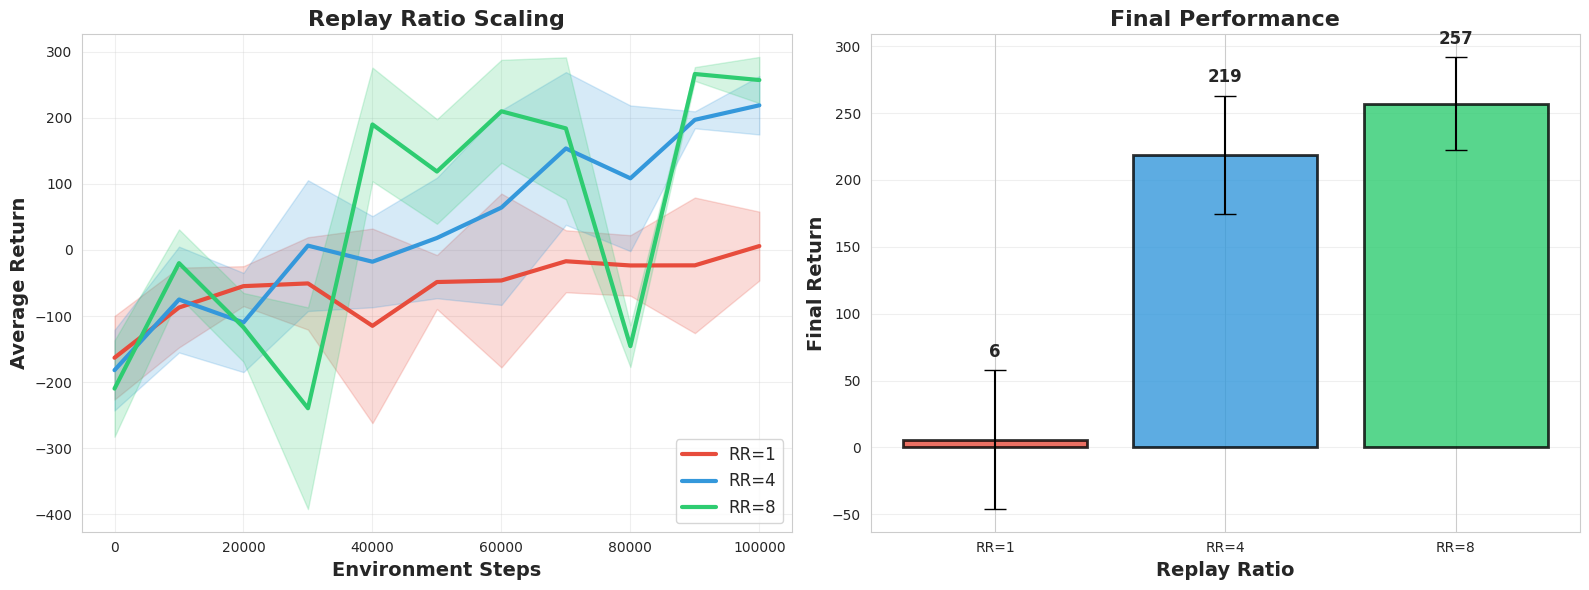

In [ ]:
def plot_rr_scaling(results_df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {1: '#E74C3C', 4: '#3498DB', 8: '#2ECC71'}
    
    for rr in config.REPLAY_RATIOS:
        data = results_df[results_df['replay_ratio'] == rr]
        grouped = data.groupby('step')['eval_return'].agg(['mean', 'std']).reset_index()
        
        ax1.plot(grouped['step'], grouped['mean'],
                label=f'RR={rr}', color=colors.get(rr, 'gray'), linewidth=3)
        ax1.fill_between(grouped['step'],
                        grouped['mean'] - grouped['std'],
                        grouped['mean'] + grouped['std'],
                        alpha=0.2, color=colors.get(rr, 'gray'))
    
    ax1.set_xlabel('Environment Steps', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Average Return', fontsize=14, fontweight='bold')
    ax1.set_title('Replay Ratio Scaling', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=12, loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    final_means = []
    final_stds = []
    for rr in config.REPLAY_RATIOS:
        rr_data = results_df[results_df['replay_ratio'] == rr]
        finals = rr_data.groupby('seed')['eval_return'].last()
        final_means.append(finals.mean())
        final_stds.append(finals.std())
    
    bars = ax2.bar(range(len(config.REPLAY_RATIOS)), final_means,
           yerr=final_stds, capsize=8, alpha=0.8,
           color=[colors[rr] for rr in config.REPLAY_RATIOS],
           edgecolor='black', linewidth=2)
    
    ax2.set_xticks(range(len(config.REPLAY_RATIOS)))
    ax2.set_xticklabels([f'RR={rr}' for rr in config.REPLAY_RATIOS])
    ax2.set_xlabel('Replay Ratio', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Final Return', fontsize=14, fontweight='bold')
    ax2.set_title('Final Performance', fontsize=16, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, (mean, std) in enumerate(zip(final_means, final_stds)):
        ax2.text(i, mean + std + 10, f'{mean:.0f}',
                ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('exp1_rr_scaling.png', dpi=200, bbox_inches='tight')
    plt.show()

plot_rr_scaling(exp1_results)